                                            DECISION TREE CLASSIFICATION
Data Preparation:

Import Libraries & Load the dataset :

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


In [3]:
xls = pd.ExcelFile('heart_disease.xlsx')
print(xls.sheet_names)

['Description', 'Heart_disease']


In [4]:
heart = pd.read_excel(xls, sheet_name='Heart_disease')
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,thal,num
0,63,Male,typical angina,145,233,True,lv hypertrophy,150,False,2.3,downsloping,fixed defect,0
1,41,Male,atypical angina,135,203,False,normal,132,False,0.0,flat,fixed defect,0
2,57,Male,asymptomatic,140,192,False,normal,148,False,0.4,flat,fixed defect,0
3,52,Male,typical angina,118,186,False,lv hypertrophy,190,False,0.0,flat,fixed defect,0
4,57,Male,asymptomatic,110,201,False,normal,126,True,1.5,flat,fixed defect,0


Basic Dataset Info :

In [5]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 908 entries, 0 to 907
Data columns (total 13 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       908 non-null    int64  
 1   sex       908 non-null    object 
 2   cp        908 non-null    object 
 3   trestbps  908 non-null    int64  
 4   chol      908 non-null    int64  
 5   fbs       908 non-null    bool   
 6   restecg   908 non-null    object 
 7   thalch    908 non-null    int64  
 8   exang     908 non-null    object 
 9   oldpeak   846 non-null    float64
 10  slope     908 non-null    object 
 11  thal      908 non-null    object 
 12  num       908 non-null    int64  
dtypes: bool(1), float64(1), int64(5), object(6)
memory usage: 86.1+ KB


In [6]:
heart.shape

(908, 13)

EXPLORATORY DATA ANALYSIS :

Check Missing Values :

In [7]:
heart.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalch,0
exang,0
oldpeak,62


Statistical Summary :

In [8]:
heart.describe()

,age,trestbps,chol,thalch,oldpeak,num
count,908.000000,908.000000,908.000000,908.000000,846.000000,908.000000
mean,53.791850,133.430617,201.484581,135.957048,0.891253,1.008811
std,9.158031,20.401608,112.097949,26.804929,1.093875,1.144436
min,29.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.750000,120.000000,176.750000,118.000000,0.000000,0.000000
50%,54.000000,130.000000,224.000000,138.000000,0.500000,1.000000
75%,60.000000,144.000000,270.000000,156.000000,1.500000,2.000000
max,77.000000,200.000000,603.000000,202.000000,6.200000,4.000000


Box Plot :

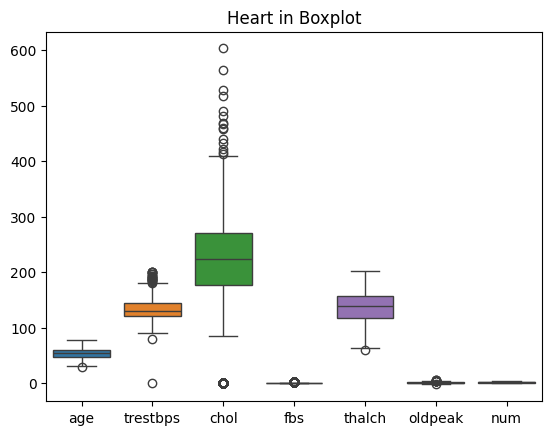

In [9]:
sns.boxplot(data=heart)
plt.title('Heart in Boxplot')
plt.show()

Histogram :

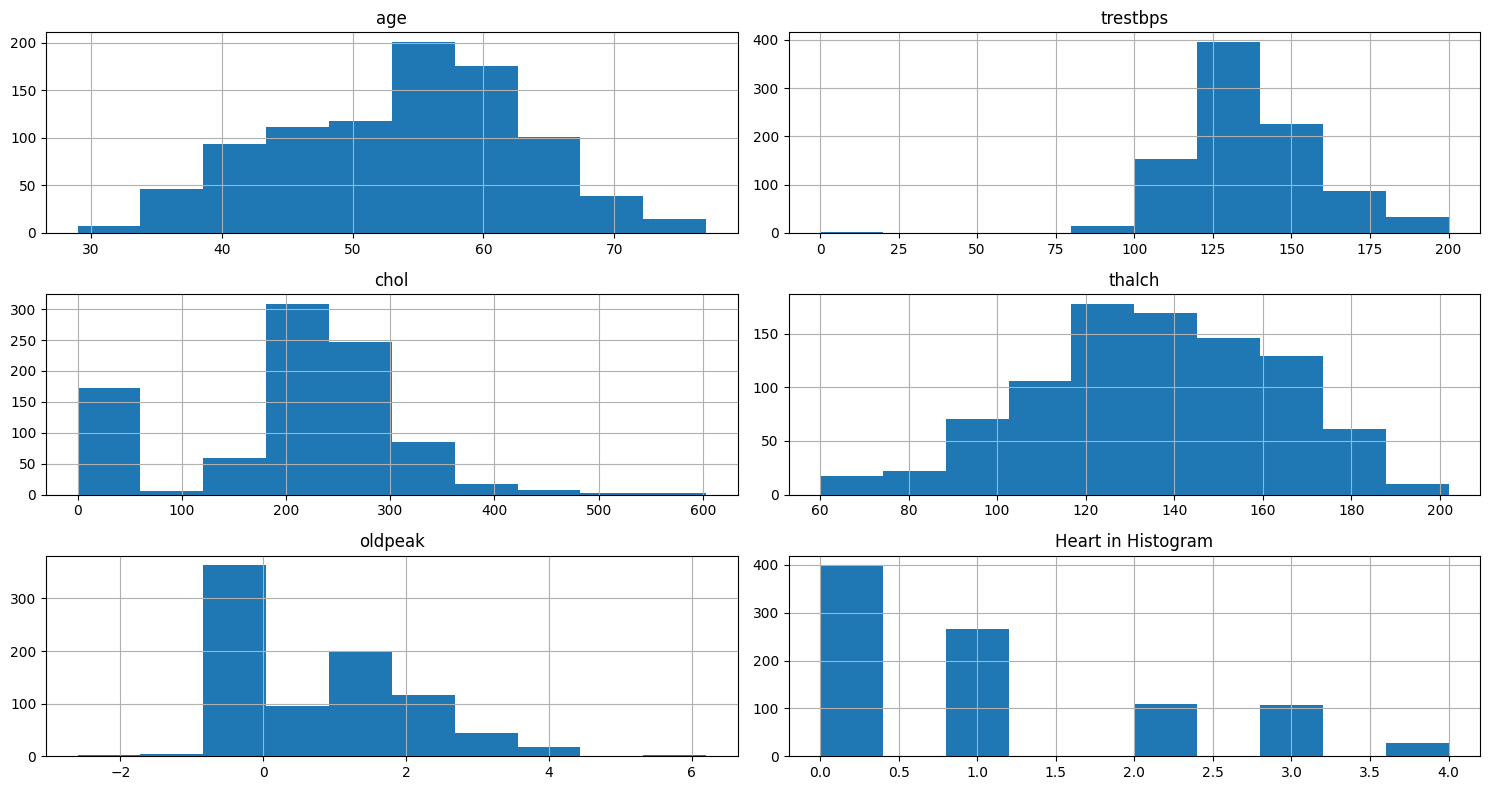

In [10]:
heart.hist(figsize=(15,8))
plt.title('Heart in Histogram')
plt.tight_layout()
plt.show()

Correlation Analysis :

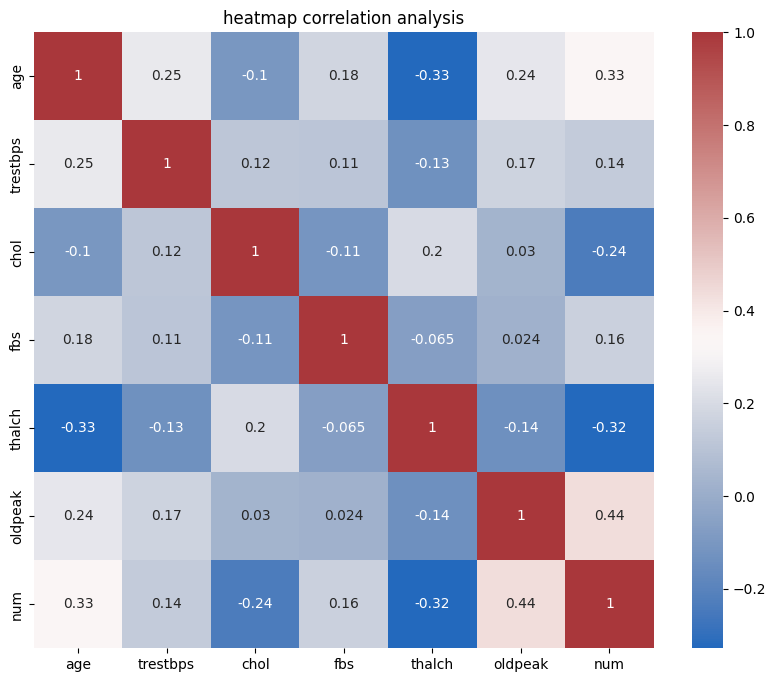

In [12]:
plt.figure(figsize=(10,8))
sns.heatmap(heart.corr(numeric_only=True), annot=True, cmap='vlag')
plt.title('heatmap correlation analysis')
plt.show()


Feature Engineering :

Encode Categorical Variables :

In [13]:
from sklearn.preprocessing import OneHotEncoder

In [14]:
heart_encoding=pd.get_dummies(heart,columns=['sex','cp','fbs','restecg','exang','slope','thal'],drop_first=True)
heart_encoding

,age,trestbps,chol,thalch,oldpeak,num,sex_Male,cp_atypical angina,cp_non-anginal,cp_typical angina,fbs_True,restecg_normal,restecg_st-t abnormality,exang_True,exang_FALSE,exang_TURE,slope_flat,slope_upsloping,thal_normal,thal_reversable defect
0,63,145,233,150,2.3,0,True,False,False,True,True,False,False,False,False,False,False,False,False,False
1,41,135,203,132,0.0,0,True,True,False,False,False,True,False,False,False,False,True,False,False,False
2,57,140,192,148,0.4,0,True,False,False,False,False,True,False,False,False,False,True,False,False,False
3,52,118,186,190,0.0,0,True,False,False,True,False,False,False,False,False,False,True,False,False,False
4,57,110,201,126,1.5,0,True,False,False,False,False,True,False,True,False,False,True,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
903,53,125,0,120,1.5,4,True,False,False,False,False,True,False,False,False,False,False,True,True,False
904,62,166,170,120,3.0,4,True,False,False,False,False,False,True,True,False,False,True,False,False,True
905,56,170,0,123,2.5,4,True,False,True,False,False,False,False,True,False,False,False,False,False,True
906,56,144,208,105,NaN,4,True,False,True,False,True,False,True,False,False,True,False,False,False,True


In [15]:
heart_encoding.dtypes

,0
age,int64
trestbps,int64
chol,int64
thalch,int64
oldpeak,float64
num,int64
sex_Male,bool
cp_atypical angina,bool
cp_non-anginal,bool
cp_typical angina,bool


Feature Split :

In [16]:
X = heart_encoding.drop('num', axis=1)
y = heart_encoding['num']

Train Test Split :

In [27]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42 )

Build the model :

In [28]:
from sklearn.tree import DecisionTreeClassifier
dtc=DecisionTreeClassifier(random_state= 42)

In [29]:
dtc.fit(x_train, y_train)

DecisionTreeClassifier(random_state=42)

In [31]:
y_pred=dtc.predict(x_test)

Evaluate The model :

In [32]:
from sklearn.metrics import classification_report,accuracy_score
print(classification_report(y_test,y_pred))
print("accuracy_score",accuracy_score(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.69      0.71      0.70        89
           1       0.29      0.29      0.29        48
           2       0.28      0.23      0.25        22
           3       0.28      0.29      0.29        17
           4       0.00      0.00      0.00         6

    accuracy                           0.48       182
   macro avg       0.31      0.30      0.31       182
weighted avg       0.47      0.48      0.48       182

accuracy_score 0.47802197802197804


In [34]:
from sklearn.metrics import roc_auc_score

y_prob = dtc.predict_proba(x_test)

roc_auc = roc_auc_score(
    y_test,
    y_prob,
    multi_class='ovr',
    average='weighted'
)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.6226913909193037


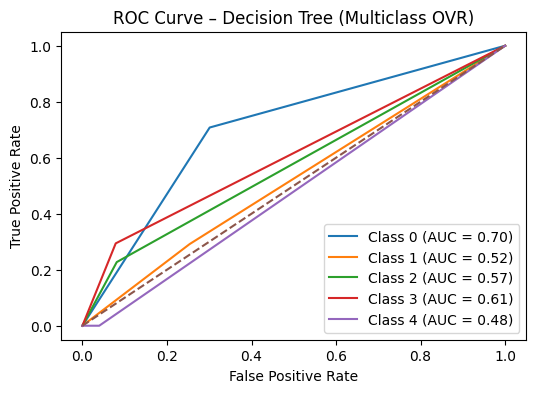

In [36]:
from sklearn.preprocessing import label_binarize
from sklearn.metrics import roc_curve, auc


classes = np.unique(y_test)
y_test_bin = label_binarize(y_test, classes=classes)


y_prob = dtc.predict_proba(x_test)

plt.figure(figsize=(6,4))

for i, cls in enumerate(classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {cls} (AUC = {roc_auc:.2f})")

plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve – Decision Tree (Multiclass OVR)")
plt.legend()
plt.show()

Hyperparamter Tuning :

In [38]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'criterion': ['gini', 'entropy']
}

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy'
)

grid.fit(x_train, y_train)

best_model = grid.best_estimator_
print("Best Parameters:", grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2}


Model Evaluation & Analysis :

In [ ]:
#Model Performance Analysis

#The Decision Tree model’s performance was evaluated using Accuracy, Precision, Recall, F1-score, and ROC-AUC.
#The results indicate how well the model distinguishes between different heart disease classes.
#Precision and Recall values show the model’s effectiveness in correctly identifying disease cases.
#ROC-AUC demonstrates the model’s ability to separate classes across different thresholds.


#Decision Tree Visualization

#The visualized decision tree shows the decision rules learned from the data.
#Each internal node represents a feature-based split, while leaf nodes represent predicted classes.
#Features appearing near the top of the tree have higher importance in classification decisions.

#Important Features

#Feature importance analysis highlights the most influential variables in predicting heart disease.
#These features contribute the most to impurity reduction and model decisions.

Decision Tree Visualization :

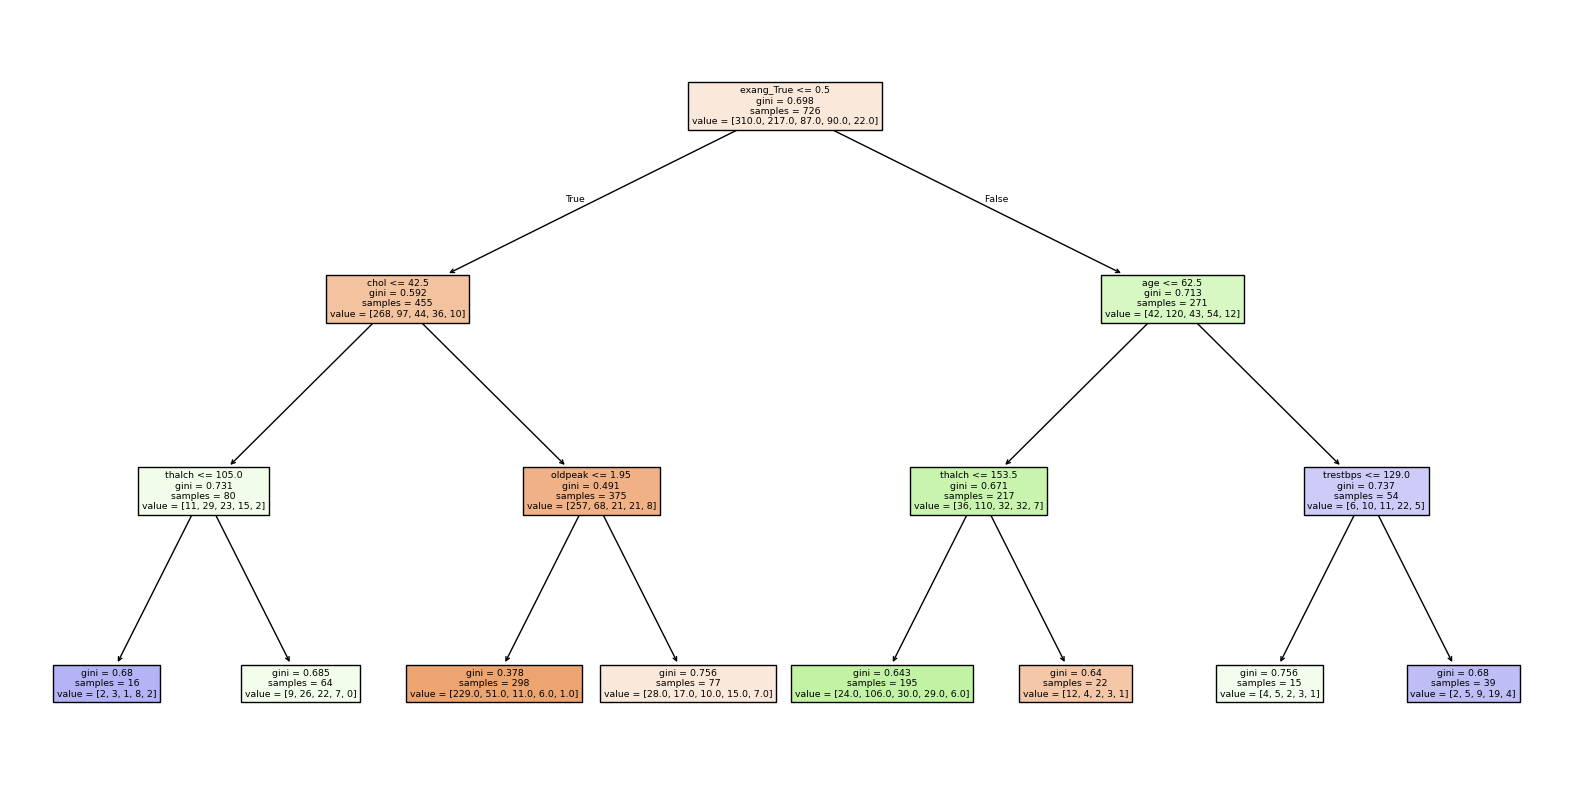

In [39]:
from sklearn.tree import plot_tree
plt.figure(figsize=(20,10))
plot_tree(
    best_model,
    feature_names=X.columns,
    filled=True
)
plt.show()

Feature_importances :

exang_True                  0.426128
chol                        0.257068
oldpeak                     0.125924
thalch                      0.096363
age                         0.075511
trestbps                    0.019006
sex_Male                    0.000000
cp_non-anginal              0.000000
cp_typical angina           0.000000
fbs_True                    0.000000
cp_atypical angina          0.000000
restecg_normal              0.000000
restecg_st-t abnormality    0.000000
exang_FALSE                 0.000000
exang_TURE                  0.000000
slope_flat                  0.000000
slope_upsloping             0.000000
thal_normal                 0.000000
thal_reversable defect      0.000000
dtype: float64


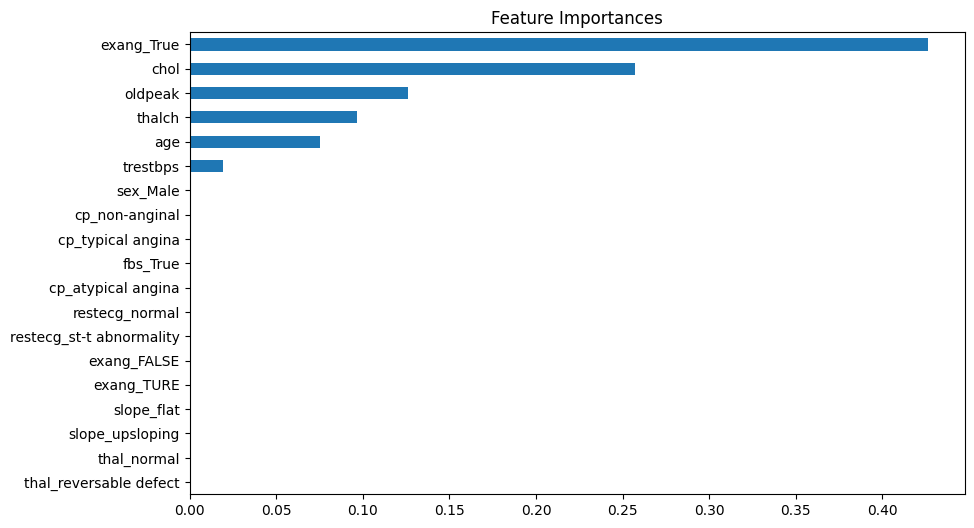

In [40]:
feature_importances = pd.Series(
    best_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(feature_importances)

feature_importances.plot(
    kind='barh',
    figsize=(10, 6),
    title='Feature Importances'
)
plt.gca().invert_yaxis()
plt.show()

In [41]:
#Interview Questions:

#1. Common Hyperparameters of Decision Trees :

#max_depth: Controls the maximum depth of the tree; prevents overfitting.
#min_samples_split: Minimum samples required to split a node.
#criterion: Measure of split quality (gini or entropy).
#min_samples_leaf: Minimum samples required at a leaf node.

#2. Label Encoding vs One-Hot Encoding

#Label Encoding :
#converts categories into integer values.
#Suitable for ordinal data
#May introduce false ranking if used on nominal data.

#One-Hot Encoding :
#It creates separate binary columns for each category.
#One-Hot Encoding avoids introducing unintended ordinal relationships.
#Suitable for nominal data